# Customer Churn — Exploratory Data Analysis

End-to-end EDA on the **real IBM Telco Customer Churn** dataset (7,043 customers):
distributions, churn drivers, correlations, and a baseline XGBoost model with
feature importance.

**Goal:** understand *why* customers churn before modelling.

> Data is loaded from `data/telco_churn.csv`, produced by
> `data/load_telco.py` from the public IBM Telco CSV. If that file is absent,
> the cell below falls back to the synthetic generator.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

## 1. Load the data

In [2]:
from data.generate_data import generate

csv_path = "../data/telco_churn.csv"
df = pd.read_csv(csv_path) if os.path.exists(csv_path) else generate(7043)
print(df.shape)
df.head()

(7043, 11)


,tenure,monthly_charges,total_charges,num_products,has_internet,has_phone,contract_type,payment_method,paperless_billing,senior_citizen,churn
0,1,29.85,29.85,2,1,0,0,0,1,0,0
1,34,56.95,"1,889.50",4,1,1,1,1,0,0,0
2,2,53.85,108.15,4,1,1,0,1,1,0,1
3,45,42.30,"1,840.75",4,1,0,1,2,0,0,0
4,2,70.70,151.65,2,1,1,0,0,1,0,1


In [3]:
df.describe()

,tenure,monthly_charges,total_charges,num_products,has_internet,has_phone,contract_type,payment_method,paperless_billing,senior_citizen,churn
count,"7,043.00","7,043.00","7,043.00","7,043.00","7,043.00","7,043.00","7,043.00","7,043.00","7,043.00","7,043.00","7,043.00"
mean,32.37,64.76,"2,279.73",4.15,0.78,0.90,0.69,1.32,0.59,0.16,0.27
std,24.56,30.09,"2,266.79",2.31,0.41,0.30,0.83,1.15,0.49,0.37,0.44
min,0.00,18.25,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,9.00,35.50,398.55,2.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00
50%,29.00,70.35,"1,394.55",4.00,1.00,1.00,0.00,1.00,1.00,0.00,0.00
75%,55.00,89.85,"3,786.60",6.00,1.00,1.00,1.00,2.00,1.00,0.00,1.00
max,72.00,118.75,"8,684.80",9.00,1.00,1.00,2.00,3.00,1.00,1.00,1.00


## 2. Target balance
Churn is imbalanced (~26.5% in the real Telco data). Accuracy alone is
misleading — we lean on ROC-AUC and recall instead.

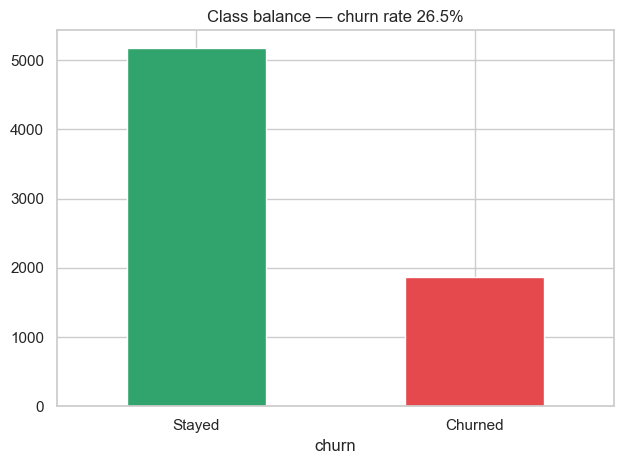

In [4]:
rate = df["churn"].mean()
ax = df["churn"].value_counts().plot(kind="bar", color=["#30a46c", "#e5484d"])
ax.set_xticklabels(["Stayed", "Churned"], rotation=0)
ax.set_title(f"Class balance — churn rate {rate:.1%}")
plt.tight_layout(); plt.show()

## 3. Churn by contract type
Month-to-month customers churn far more than those on 1- or 2-year contracts.

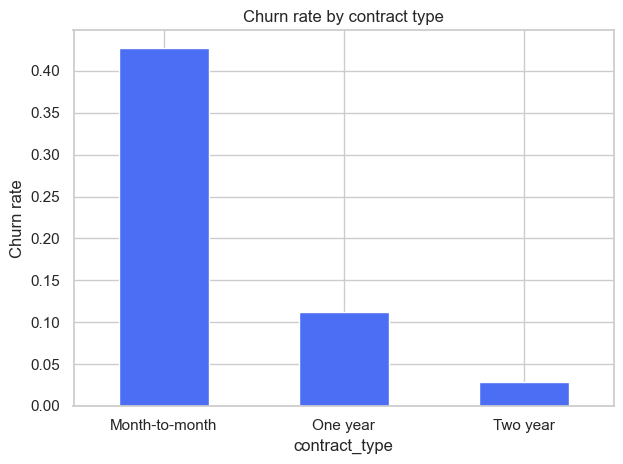

In [5]:
contract_churn = df.groupby("contract_type")["churn"].mean()
ax = contract_churn.plot(kind="bar", color="#4c6ef5")
ax.set_xticklabels(["Month-to-month", "One year", "Two year"], rotation=0)
ax.set_ylabel("Churn rate"); ax.set_title("Churn rate by contract type")
plt.tight_layout(); plt.show()

## 4. Tenure vs churn
New customers are the flight risk; churn drops steadily with tenure.

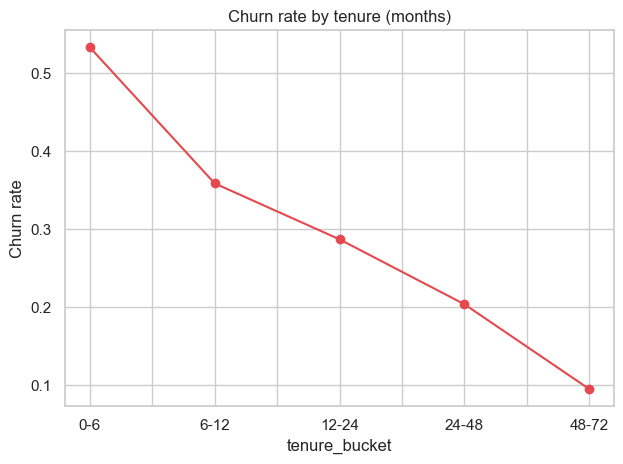

In [6]:
df["tenure_bucket"] = pd.cut(df["tenure"], bins=[0, 6, 12, 24, 48, 72],
                             labels=["0-6", "6-12", "12-24", "24-48", "48-72"])
ax = df.groupby("tenure_bucket", observed=True)["churn"].mean().plot(kind="line", marker="o", color="#e5484d")
ax.set_ylabel("Churn rate"); ax.set_title("Churn rate by tenure (months)")
plt.tight_layout(); plt.show()

## 5. Correlation heatmap
Which numeric features move together, and which correlate with churn.

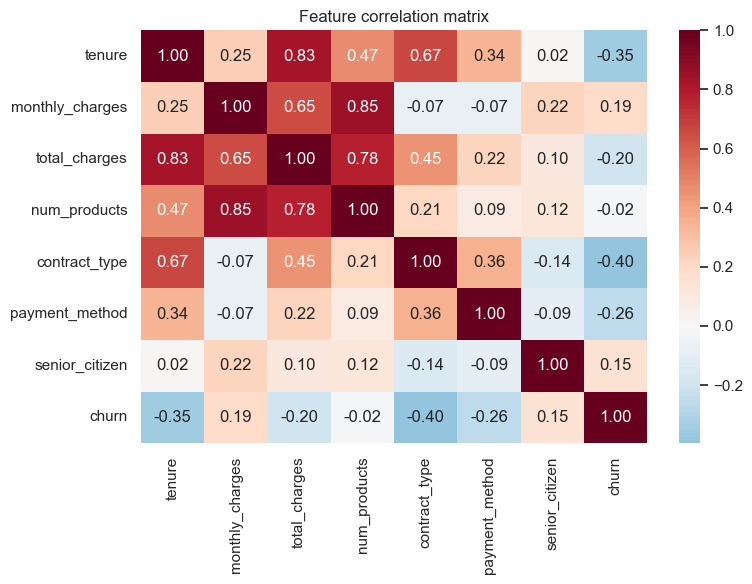

In [7]:
num_cols = ["tenure", "monthly_charges", "total_charges", "num_products",
            "contract_type", "payment_method", "senior_citizen", "churn"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Feature correlation matrix"); plt.tight_layout(); plt.show()

## 6. Monthly charges distribution by churn
Churners skew toward higher monthly bills.

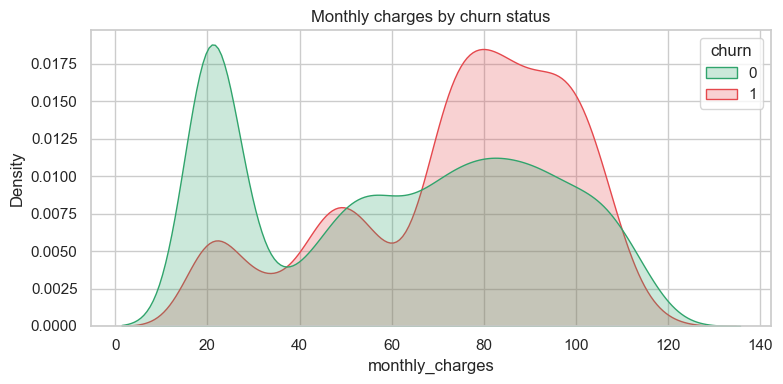

In [8]:
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x="monthly_charges", hue="churn", fill=True,
            palette=["#30a46c", "#e5484d"], common_norm=False)
plt.title("Monthly charges by churn status"); plt.tight_layout(); plt.show()

## 7. Baseline model + feature importance
Train the production pipeline and inspect what the model relies on.

In [9]:
from app.model import train

metrics = train(df, save=False)
print({k: metrics[k] for k in ["accuracy", "roc_auc", "precision", "recall", "f1"]})

{'accuracy': 0.7594, 'roc_auc': 0.8332, 'precision': 0.5338, 'recall': 0.738, 'f1': 0.6195}


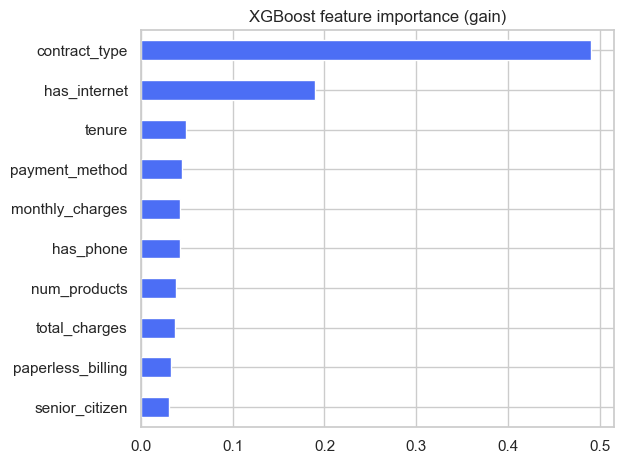

In [10]:
imp = metrics["feature_importance"]
ax = pd.Series(imp).sort_values().plot(kind="barh", color="#4c6ef5")
ax.set_title("XGBoost feature importance (gain)"); plt.tight_layout(); plt.show()

## Takeaways
- **Contract type, internet service, and tenure** dominate churn risk.
- The dataset is imbalanced (~26.5% churn), so we optimize for **ROC-AUC (~0.83)**
  and **recall (~0.74)** rather than raw accuracy (~0.76).
- `scale_pos_weight` in XGBoost lifts recall on churners — the customers a
  retention team actually wants to catch.